# 03. Setul semisintetic, blocarea și vectorul de comparare

**Proiect:** Integrarea probabilistă a registrelor farmaceutice oficiale din Republica Moldova și analiza prețurilor medicamentelor echivalente.
**Autor:** Olesea Popa, grupa SD251M, UTM.

Lista CNAM a medicamentelor compensate nu are codul medicamentului, așa că fiecare rând al ei trebuie legat de Nomenclatorul AMDM printr-un model de potrivire. Un astfel de model are nevoie de exemple pentru care răspunsul corect este cunoscut, atât ca să fie antrenat, cât și ca să-i alegem pragurile. Cele 200 de rânduri CNAM etichetate manual nu pot fi folosite pentru asta, pentru că ele sunt păstrate pentru evaluarea finală. Perechile dintre Catalogul de prețuri și Nomenclator au răspunsul cunoscut prin cod, dar analiza exploratorie a arătat că textul lor este identic în 99,9% din cazuri, deci sunt prea ușoare.

Acest notebook rezolvă problema prin trei pași. Mai întâi măsurăm cât de des și în ce fel diferă lista CNAM de Nomenclator. Apoi construim un set semisintetic, adică luăm rândurile Catalogului și introducem în textul lor, cu aceleași frecvențe, felurile de diferențe găsite în CNAM, păstrând răspunsul corect dat de cod. În final aplicăm pe acest set și pe lista CNAM aceiași doi pași ai potrivirii: blocarea, care alege perechile candidate, și vectorul de comparare, care descrie fiecare pereche prin câteva scoruri de asemănare. Codul se află în fișierele src/blocking.py, src/compare.py și src/semisynthetic.py, iar funcțiile noi de normalizare au fost adăugate în src/normalize.py.

## 0. Pregătirea mediului

**Ce căutăm.** Încărcăm modulele proiectului și datele normalizate salvate de notebook-ul 02. Apoi adăugăm pe toate cele trei surse, cu aceleași funcții, câmpurile de care are nevoie potrivirea: rădăcina substanței active, numele firmei fără forma juridică și divizarea exprimată ca număr total de unități și volum.

In [1]:
import sys
from pathlib import Path
import numpy as np                 # calcule numerice
import pandas as pd                # tabele de date
import matplotlib.pyplot as plt    # grafice
import seaborn as sns              # grafice statistice, peste matplotlib

# Rădăcina proiectului: funcționează fie că notebook-ul e pornit din notebooks/, fie din SD_utm/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from clean import key_text
from normalize import normalize_linkage, country_set                       # pasul 3: câmpuri noi pentru potrivire
from blocking import candidate_pairs, blocking_metrics                     # pasul 5: blocarea
from compare import compare, SIM_COLS, LEVEL_COLS                          # pasul 6: vectorul de comparare
from semisynthetic import (probable_pairs, estimate_rates, product_class,  # setul semisintetic
                           build_semisynthetic, true_pairs, SEED)

FIG = ROOT / "reports" / "figures"
INTERIM = ROOT / "data" / "interim"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight"})
pd.set_option("display.max_colwidth", 60, "display.width", 200)

# Datele normalizate, salvate de notebook-ul 02 (citite ca text, ca să nu pierdem zerourile din coduri)
n  = pd.read_csv(INTERIM / "nomenclator_norm.csv", dtype=str)
c  = pd.read_csv(INTERIM / "catalog_norm.csv", dtype=str)
ro = pd.read_csv(INTERIM / "cnam_ro_norm.csv", dtype=str)

# Câmpurile noi, calculate identic pe toate sursele; țările sunt luate din coloanele „tara”
COUNTRIES = country_set(n.tara, c.tara, ro.tara)
n  = normalize_linkage(n,  ["detinator", "producator"], COUNTRIES)  # Nomenclator: deținător + coloana producătorilor
c  = normalize_linkage(c,  ["detinator"], COUNTRIES)                # Catalog: producătorii sunt în „(PROD: ...)”
ro = normalize_linkage(ro, ["producator"], COUNTRIES)               # CNAM: o singură coloană de firmă
print({k: d.shape for k, d in [("Nomenclator", n), ("Catalog", c), ("CNAM RO", ro)]})

{'Nomenclator': (6242, 28), 'Catalog': (3719, 35), 'CNAM RO': (2167, 23)}


**Ce am obținut.** Cele trei surse au același număr de rânduri ca în notebook-ul 02, adică 6.242 de produse în Nomenclator, 3.719 în Catalog și 2.167 de rânduri în lista CNAM. Fiecare tabel are acum cinci coloane noi: rădăcina substanței active, numele firmei normalizat, lista tuturor firmelor asociate rândului, numărul total de unități și volumul.

## 1. Câmpuri noi pentru potrivire: substanța activă, firma și divizarea

**Ce căutăm.** Normalizarea din notebook-ul 02 a tratat denumirea, doza și forma. Potrivirea la nivel de ambalaj are nevoie și de alte trei câmpuri. Substanța activă servește la blocare. În CNAM ea este scrisă altfel decât în Nomenclator, de exemplu METFORMINUM față de Metformini hydrochloridum, așa că păstrăm doar rădăcina latină a fiecărei componente, adică primele șase litere fără cuvintele care descriu sarea. Firma deosebește produsele cu aceeași denumire generică, iar de la nume eliminăm partea dintre paranteze cu producătorii, țara și forma juridică. Divizarea este comparată, cum am stabilit, după numărul total de unități, cu volumul separat. Verificăm noile câmpuri pe perechile Catalog și Nomenclator legate prin cod, unde trebuie să fie egale, și pe perechile CNAM potrivite exact în notebook-ul 02.

In [2]:
# Exemple: cum arată câmpurile noi în fiecare sursă
show = ["dci", "dci_stem", "divizare", "volum", "unitati_norm", "volum_norm", "firma_norm"]
print(ro.loc[[0, 1155, 1856], show + ["producator"]].to_string(), "\n")

# Control 1: perechile Catalog–Nomenclator legate prin cod descriu același produs, deci câmpurile trebuie să fie egale
m = c.merge(n, on="cod", suffixes=("_c", "_n"))
def same(x, y):
    both = x.notna() & y.notna()
    return f"{(x[both] == y[both]).mean():.1%} din {both.sum()}"
print("Catalog–Nomenclator, același cod:")
print("  rădăcina DCI egală:      ", same(m.dci_stem_c, m.dci_stem_n))
print("  numărul de unități egal: ", same(m.unitati_norm_c, m.unitati_norm_n))
print("  volumul egal:            ", same(m.volum_norm_c, m.volum_norm_n))
print("  deținătorul egal:        ", same(m.firma_norm_c, m.firma_norm_n))

# Control 2: perechile CNAM–Nomenclator potrivite exact în notebook-ul 02 (denumire, doză, formă)
e = ro.merge(n, on=["denumire_norm", "doza_norm", "forma_norm"], suffixes=("_r", "_n"))
e = e.drop_duplicates(subset=["denumire_norm", "doza_norm", "forma_norm", "dci_r"])
print("\nCNAM–Nomenclator, potrivite exact:")
print("  DCI egală ca text curățat:", same(key_text(e.dci_r), key_text(e.dci_n)))
print("  rădăcina DCI egală:       ", same(e.dci_stem_r, e.dci_stem_n))

                           dci dci_stem divizare   volum  unitati_norm volum_norm        firma_norm                                                                producator
0                ACECLOFENACUM   aceclo   N10x10     NaN         100.0        NaN  kusum healthcare  Kusum Healthcare Pvt.Ltd, India(PROD: Kusum Healthcare Pvt.Ltd, India; )
1155  ACIDUM URSODEOXYCHOLICUM   ursode    N10x6     NaN          60.0        NaN            balkan                                            Balkan Pharmaceuticals SRL, SC
1856          NATRII CHLORIDUM   chlori       N1  200 ml           1.0     200 ml             iuria                                                            Iuria-Farm SRL 

Catalog–Nomenclator, același cod:
  rădăcina DCI egală:       100.0% din 3422
  numărul de unități egal:  100.0% din 3650
  volumul egal:             100.0% din 1428
  deținătorul egal:         100.0% din 3651

CNAM–Nomenclator, potrivite exact:
  DCI egală ca text curățat: 92.6% din 983
  rădăcina DC

**Ce am obținut.** Exemplele arată cum funcționează noile câmpuri. ACECLOFENACUM devine aceclo, divizarea N10x10 devine 100 de unități, iar firma Kusum Healthcare Pvt.Ltd, India, urmată de paranteza cu producătorul, devine kusum healthcare. La soluția de clorură de sodiu în flacon de 200 ml divizarea devine o unitate, iar volumul este păstrat separat. Pe perechile Catalog și Nomenclator legate prin cod, toate cele patru câmpuri noi sunt identice în 100% din cazuri, deci normalizarea tratează la fel cele două surse. Pe cele 983 de combinații CNAM potrivite exact cu Nomenclatorul, substanța activă scrisă ca text curățat coincide doar în 92,6% din cazuri, în timp ce rădăcina ei coincide în 100% din cazuri.

**Constatare 1.** Reducerea substanței active la rădăcinile latine ale componentelor elimină diferențele de scriere dintre lista CNAM și Nomenclator, ridicând acordul de la 92,6% la 100% pe perechile potrivite exact. Normalizarea firmei și a divizării nu creează diferențe între perechile cu același cod, unde acordul rămâne de 100%.

## 2. Blocarea pe lista CNAM

**Ce căutăm.** Fiecare rând CNAM ar putea fi comparat cu fiecare dintre cele 6.242 de produse ale Nomenclatorului, dar aproape toate aceste perechi sunt evident diferite. Blocarea păstrează doar perechile care au în comun rădăcina substanței active sau primele patru litere ale denumirii. A doua cheie este o rezervă pentru produsele la care Nomenclatorul scrie doar Combinaţie în locul substanței și pentru denumirile scrise foarte diferit. Măsurăm câte perechi rămân și verificăm că perechile potrivite exact în notebook-ul 02 nu se pierd.

In [3]:
pairs_cnam = candidate_pairs(ro, n)
bm = blocking_metrics(pairs_cnam, len(ro), len(n))
print(pd.Series(bm).to_string())
print("\nCe cheie a adus perechea:", pairs_cnam.bloc.value_counts().to_dict())

# Controlul de completitudine pe CNAM: perechile exacte din notebook-ul 02 trebuie să fie printre candidați
ex = (ro.reset_index().rename(columns={"index": "ia"})
        .merge(n.reset_index().rename(columns={"index": "ib"}), on=["denumire_norm", "doza_norm", "forma_norm"])[["ia", "ib"]])
found = ex.merge(pairs_cnam, on=["ia", "ib"], how="left", indicator=True)
print(f"\nPerechi exacte CNAM–Nomenclator: {len(ex)}; printre candidați: {(found._merge == 'both').mean():.2%}")
print("Rânduri CNAM fără niciun candidat:")
print(ro.loc[sorted(set(ro.index) - set(pairs_cnam.ia)), ["dci", "denumire", "doza", "forma"]].to_string())

perechi candidate               7.380000e+04
perechi posibile                1.352641e+07
rata de reducere                9.945440e-01
candidați pe rând (median)      2.600000e+01
rânduri fără niciun candidat    2.000000e+00

Ce cheie a adus perechea: {'dci': 48630, 'dci+nume': 17356, 'nume': 7814}

Perechi exacte CNAM–Nomenclator: 4763; printre candidați: 100.00%
Rânduri CNAM fără niciun candidat:
                                    dci     denumire                  doza                           forma
544   IPRATROPII BROMIDUM + FENOTEROLUM  Berodual® N  20 mcg + 50 mcg/doză  soluţie de inhalat presurizată
1668  IPRATROPII BROMIDUM + FENOTEROLUM  Berodual® N  20 mcg + 50 mcg/doză  soluţie de inhalat presurizată


**Ce am obținut.** Din cele aproximativ 13,5 milioane de perechi posibile dintre lista CNAM și Nomenclator, blocarea păstrează 73.800, deci elimină 99,45% dintre ele. Un rând CNAM are în mediană 26 de candidați. Cheia substanței active aduce singură 48.630 de perechi, prefixul denumirii aduce singur 7.814, iar 17.356 de perechi sunt aduse de ambele chei. Toate cele 4.763 de perechi exacte găsite în notebook-ul 02 se află printre candidați. Doar două rânduri CNAM nu au niciun candidat, ambele pentru Berodual N, un medicament care nu apare deloc în Nomenclator.

**Constatare 2.** Blocarea după rădăcina substanței active, completată de prefixul denumirii, reduce numărul comparațiilor cu 99,45%, la o mediană de 26 de candidați pentru fiecare rând CNAM, fără să piardă nicio pereche potrivită exact. Prefixul denumirii aduce singur 10,6% dintre perechi, în special pentru produsele la care Nomenclatorul nu indică substanța activă.

## 3. Vectorul de comparare și cât de des diferă CNAM de Nomenclator

**Ce căutăm.** Pentru fiecare pereche candidată calculăm vectorul de comparare. La denumire folosim două măsuri de asemănare a textului. Prima este Jaro–Winkler, sensibilă la greșelile de litere. A doua compară cuvintele, deci nu penalizează un cuvânt în plus. La doză și formă reținem dacă sunt egale și ce parte din componente, respectiv din cuvinte, au în comun. La divizare reținem dacă numărul de unități și volumul sunt egale. La firmă reținem cea mai mare asemănare dintre oricare deținător sau producător al celor două rânduri. Fiecare scor are și o variantă în trepte, numită nivel de acord, de exemplu identic, asemănător sau diferit, de care are nevoie modelul Fellegi–Sunter.

In [4]:
vec_cnam = compare(pairs_cnam, ro, n)
print(f"Perechi comparate: {len(vec_cnam)}; coloane continue: {SIM_COLS}")
print(f"Niveluri pentru Fellegi–Sunter: {LEVEL_COLS}\n")
# distribuția nivelurilor pe toate perechile candidate (<NA> = câmp lipsă în una dintre surse)
pd.DataFrame({col: vec_cnam[col].value_counts(dropna=False).sort_index() for col in LEVEL_COLS}).T.fillna(0).astype(int)

Perechi comparate: 73800; coloane continue: ['sim_denumire', 'sim_denumire_tok', 'eq_doza', 'sim_doza', 'eq_forma', 'sim_forma', 'eq_unitati', 'eq_volum', 'sim_firma', 'eq_dci']
Niveluri pentru Fellegi–Sunter: ['niv_denumire', 'niv_doza', 'niv_forma', 'niv_unitati', 'niv_volum', 'niv_firma', 'niv_dci']



,0,1,2,3,<NA>
niv_denumire,52518,9483,3095,8659,45
niv_doza,46265,2286,24906,0,343
niv_forma,28763,6827,38165,0,45
niv_unitati,51260,22473,0,0,67
niv_volum,7199,3828,0,0,62773
niv_firma,62997,1838,8775,0,190
niv_dci,7579,65986,0,0,235


**Ce am obținut.** Toate cele 73.800 de perechi candidate au acum zece scoruri continue și șapte niveluri de acord. Majoritatea candidaților sunt evident alte produse. Denumirea are nivelul cel mai scăzut în 52.518 perechi și este identică doar în 8.659. Volumul lipsește în 62.773 de perechi, adică în 85% dintre ele, deoarece el este indicat doar pentru formele lichide și semisolide. Pentru celelalte forme acest câmp nu aduce informație, iar modelul îl va trata ca lipsă, nu ca dezacord.

**Ce căutăm.** Ca să construim un set semisintetic realist, trebuie să știm cât de des diferă fiecare câmp între un rând CNAM și produsul lui din Nomenclator. Nu cunoaștem perechea corectă, dar o putem aproxima. Pentru fiecare rând CNAM luăm candidatul cu cele mai multe câmpuri asemănătoare și îl păstrăm doar dacă denumirea are o asemănare Jaro–Winkler de cel puțin 0,85. Pe aceste perechi probabile numărăm cât de des diferă fiecare câmp. Frecvențele sunt limite superioare, pentru că o parte dintre perechile probabile sunt de fapt produse diferite.

In [5]:
best_cnam = probable_pairs(vec_cnam)
RATES = estimate_rates(best_cnam, ro, n, firm_col="producator")
print(f"Perechi probabile: {len(best_cnam)} din {len(ro)} rânduri CNAM\n")
print((pd.Series(RATES) * 100).round(2).rename("% din perechile probabile").to_string())

Perechi probabile: 2073 din 2167 rânduri CNAM

denumire                2.36
forma                   2.46
doza                    0.82
firma_alt_detinator     3.33
firma_format_scurt     39.36
divizare_notatie       10.61
volum_in_divizare       4.68
volum_lipsa             1.74


**Ce am obținut.** Pentru 2.073 din cele 2.167 de rânduri CNAM, adică 95,7%, am găsit o pereche probabilă. Diferențele de conținut sunt rare. Denumirea diferă în 2,4% din perechi, forma în 2,5%, doza în 0,8%, iar deținătorul în 3,3%. Diferențele de scriere sunt mult mai frecvente, dar normalizarea le tratează. Firma este scrisă fără paranteza cu producătorii în 39,4% din rânduri, divizarea apare în altă notație, de exemplu N30 în loc de N10x3, în 10,6% din rânduri, iar volumul este trecut în textul divizării în 4,7% din rânduri și lipsește în 1,7%.

**Ce căutăm.** Frecvențele spun cât de des diferă un câmp, dar nu și cum diferă. Citim de aceea direct perechile probabile cu denumiri sau forme diferite. Pe baza lor am ales tipurile de variații și ponderile lor în generator, de exemplu cât de des e o greșeală de literă și cât de des un cuvânt în plus.

In [6]:
A, B = ro.loc[best_cnam.ia].reset_index(drop=True), n.loc[best_cnam.ib].reset_index(drop=True)
bc = best_cnam.reset_index(drop=True)
diff_name = pd.DataFrame({"denumire CNAM": A.denumire, "denumire Nomenclator": B.denumire,
                          "Jaro–Winkler": bc.sim_denumire.round(3)})[bc.niv_denumire < 3]
print(diff_name.drop_duplicates().sort_values("Jaro–Winkler", ascending=False).head(15).to_string(), "\n")
diff_form = pd.DataFrame({"forma CNAM": A.forma_norm, "forma Nomenclator": B.forma_norm})[bc.eq_forma == 0]
print(diff_form.value_counts().head(10).to_string())

                      denumire CNAM                                  denumire Nomenclator  Jaro–Winkler
11               Cardiosalin Protec                                   Cardiosalin Protect         0.989
432              Famotidin Sopharma                                   Famotidine Sopharma         0.989
83                      Amoxicilină                                            Amoxicilin         0.982
1254                     Bicilin®-5                                            Bicillin-5         0.980
1253                     Bicilin®-3                                            Bicillin-3         0.980
855                       Rivaroxia                                               Rivarox         0.956
958                Spironolacton-LF                                      Spironolacton-BP         0.950
541                       Lerkamen®                                          Lerkamen® 10         0.945
539                       Lerkamen®                             

**Ce am obținut.** Diferențele de denumire sunt de câteva tipuri. Unele sunt greșeli de o literă, ca Cardiosalin Protec în loc de Cardiosalin Protect sau Bicilin în loc de Bicillin. Altele sunt terminații diferite, ca Famotidin și Famotidine sau Amoxicilină și Amoxicilin. Mai apar cuvinte în plus, ca în Clorură de sodiu - Jurabek, și numere lipite de nume, ca la Lerkamen 10. Unele perechi probabile sunt de fapt produse diferite, de exemplu Torasemid și Torsid sau Spironolacton-LF și Spironolacton-BP, care au firme diferite. Aceasta confirmă că frecvențele estimate sunt limite superioare. La formă, diferențele constau aproape mereu într-un cuvânt lipsă sau în plus, cum sunt filmate, unidoza sau cu, într-o ordine diferită a cuvintelor sau în confuzia dintre soluție și suspensie. Pe baza acestor exemple am ales tipurile de variații ale generatorului și ponderile lor.

**Constatare 3.** După normalizare, un rând CNAM diferă de perechea lui probabilă din Nomenclator prin denumire în aproximativ 2,4% din cazuri, prin formă în 2,5%, prin doză în 0,8% și prin deținător în 3,3%. Diferențele sunt puține și se încadrează în câteva tipuri recurente, ca greșelile de o literă, terminațiile, cuvintele în plus sau lipsă și confuzia soluție–suspensie, ceea ce permite imitarea lor controlată.

## 4. Setul semisintetic

**Ce căutăm.** Înainte de a construi setul trebuie să stabilim ce înseamnă răspunsul corect. Nomenclatorul dă uneori coduri diferite aceluiași medicament ambalat diferit, de exemplu Acard 75 mg în cutie N30 și în cutie N10x3. Noi comparăm divizarea după numărul total de unități, deci din punctul de vedere al potrivirii acestea sunt același produs. Grupăm de aceea rândurile Nomenclatorului în clase de produs, cu aceeași denumire, doză, formă, număr de unități, volum și deținător, și considerăm corectă orice potrivire cu un cod din clasa corectă.

In [7]:
n["clasa_produs"] = product_class(n)
size = n.clasa_produs.map(n.clasa_produs.value_counts())
print(f"Coduri în Nomenclator: {n.cod.nunique()}; clase de produs: {n.clasa_produs.nunique()}")
print(f"Coduri care împart clasa cu alt cod: {n.cod[size > 1].nunique()} ({(size > 1).mean():.1%})")
n.loc[n.denumire_norm.str.startswith("acard", na=False) & (n.doza_norm == "75 mg"),
      ["cod", "denumire", "doza", "forma", "divizare", "unitati_norm", "clasa_produs"]].sort_values("unitati_norm")

Coduri în Nomenclator: 6242; clase de produs: 5938
Coduri care împart clasa cu alt cod: 564 (9.0%)


,cod,denumire,doza,forma,divizare,unitati_norm,clasa_produs
2891,2006330097,Acard®,75 mg,comprimate gastrorezistente,N30,30.0,24
2898,2006330101,Acard®,75 mg,comprimate gastrorezistente,N10x3,30.0,24
2897,2006330053,Acard®,75 mg,comprimate gastrorezistente,N10x5,50.0,25
2893,2006330112,Acard®,75 mg,comprimate gastrorezistente,N25x2,50.0,25
2895,2006330123,Acard®,75 mg,comprimate gastrorezistente,N30x2,60.0,26
2894,2006330134,Acard®,75 mg,comprimate gastrorezistente,N10x6,60.0,26
2892,2006330086,Acard®,75 mg,comprimate gastrorezistente,N20x5,100.0,27
2896,2006330145,Acard®,75 mg,comprimate gastrorezistente,N25x4,100.0,27


**Ce am obținut.** Cele 6.242 de coduri ale Nomenclatorului formează 5.938 de clase de produs, iar 564 de coduri, adică 9,0%, împart clasa cu un alt cod. Exemplul Acard 75 mg arată situația tipică. Cele opt coduri formează patru clase, de 30, 50, 60 și 100 de comprimate, iar fiecare cantitate există în două ambalaje diferite, de exemplu N30 și N10x3. Dacă am considera corect doar codul exact, un model care alege N10x3 pentru un rând CNAM scris N30 ar fi penalizat, deși regula noastră îl consideră același produs.

**Ce căutăm.** Construim acum setul. Pornim de la produsele Catalogului care au cod în Nomenclator și introducem în textul lor brut variații de felul celor găsite în CNAM. Probabilitatea fiecărei variații este frecvența estimată mai sus. Apoi trecem textul prin aceeași normalizare ca pe CNAM, astfel încât rămân doar diferențele pe care normalizarea nu le poate repara. Numărul de unități din ambalaj nu se schimbă niciodată, pentru că alt ambalaj înseamnă alt produs, nu altă scriere. Pentru o parte din rânduri scoatem produsul corect din copia Nomenclatorului, ca modelul să învețe să spună că nu există pereche. Proporția lor este de 5,5%, cât am estimat din etichetarea manuală pentru întreaga listă CNAM. Facem două variante. Setul realist folosește exact frecvențele din CNAM. Setul amplificat folosește variații de cinci ori mai frecvente și de două ori mai multe rânduri fără pereche, ca modelele să vadă destule cazuri dificile la antrenare.

In [8]:
VARIANTE = {"realist": dict(factor=1, p_no_pair=0.055), "amplificat": dict(factor=5, p_no_pair=0.11)}
ss = {}
for name, par in VARIANTE.items():
    a, b = build_semisynthetic(c, n.drop(columns="clasa_produs"), RATES, COUNTRIES, seed=SEED, **par)
    ss[name] = {"a": a, "b": b}

rez = pd.DataFrame({name: {
    "rânduri (produse din Catalog)": len(d["a"]),
    "produse în copia Nomenclatorului": len(d["b"]),
    "% rânduri cu cel puțin o variație": (d["a"].variatii != "").mean() * 100,
    "% rânduri fără pereche": (~d["a"].are_pereche).mean() * 100,
    "  din care: marca lipsește": (d["a"].fara_pereche_tip == "marca").sum(),
    "  din care: doar produsul lipsește": (d["a"].fara_pereche_tip == "produs").sum(),
} for name, d in ss.items()}).round(1)
print(rez.to_string(), "\n")
# câte variații de fiecare tip
pd.DataFrame({name: d["a"].variatii.str.split(";").explode().loc[lambda s: s != ""].value_counts()
              for name, d in ss.items()}).fillna(0).astype(int).sort_values("amplificat", ascending=False)

                                    realist  amplificat
rânduri (produse din Catalog)        3653.0      3653.0
produse în copia Nomenclatorului     5979.0      5707.0
% rânduri cu cel puțin o variație      15.8        57.9
% rânduri fără pereche                  5.5        11.0
  din care: marca lipsește            192.0       366.0
  din care: doar produsul lipsește     10.0        35.0 



,realist,amplificat
variatii,,
divizare:notatie,227,1123
firma:alt_detinator,95,475
forma:cuvant_lipsa,43,195
denumire:greseala,39,151
doza:lipsa,18,137
volum:lipsa,28,114
denumire:terminatie,17,93
forma:cuvant_in_plus,20,87
forma:alta_forma,20,79


**Ce am obținut.** Ambele variante au 3.653 de rânduri, adică produsele Catalogului care au cod în Nomenclator. În setul realist, 15,8% dintre rânduri au cel puțin o variație, iar 5,5% nu au pereche, 192 pentru că marca a fost scoasă din Nomenclator și 10 pentru că a fost scos doar acel produs. În setul amplificat, 57,9% dintre rânduri au cel puțin o variație, iar 11,0% nu au pereche, 366 cu marca lipsă și 35 cu produsul lipsă. Rândurile fără pereche de tip produs sunt puține deoarece scoaterea unei mărci lasă dintr-odată fără pereche mai multe rânduri din Catalog. Cele mai frecvente variații sunt notația diferită a divizării și deținătorul diferit. Dintre variațiile de conținut, cele mai frecvente sunt cuvântul lipsă din formă și greșeala de literă din denumire.

**Ce căutăm.** Verificăm cu ochiul liber câteva rânduri din setul amplificat, comparând textul original din Catalog cu cel modificat, ca să ne asigurăm că variațiile seamănă cu ce apare în CNAM.

In [9]:
orig = c.drop_duplicates("cod").set_index("cod")
a = ss["amplificat"]["a"]
rows = []
for _, r in a[a.variatii.str.contains("denumire|forma|doza")].sample(12, random_state=SEED).iterrows():
    o = orig.loc[r.cod_adevarat]
    for f in ["denumire", "forma", "doza"]:
        if str(o[f]) != str(r[f]):
            rows.append({"variația": r.variatii, "câmp": f, "original (Catalog)": o[f], "modificat": r[f]})
pd.DataFrame(rows)

,variația,câmp,original (Catalog),modificat
0,forma:cuvant_lipsa,forma,soluţie cutanată,solutie
1,denumire:greseala,denumire,Valsartan-BP,Valsaratn-BP
2,denumire:cuvant_lipsa,denumire,Glucoză 50 mg/ml,Glucoză 50
3,forma:cuvant_in_plus;firma:alt_detinator;divizare:notatie,forma,capsule,capsule moi
4,forma:cuvant_in_plus;firma:alt_detinator;divizare:notatie,forma,comprimate,comprimate filmate
5,forma:alta_forma,forma,pulbere pentru soluţie orală,solutie injectabila
6,forma:sinonim;volum:in_divizare,forma,suspensie injectabilă,solutie injectabila
7,forma:alta_forma,forma,gel,"spray cutanat, solutie"
8,denumire:greseala;divizare:notatie,denumire,Muscoflex®,Mrscoflex®
9,denumire:greseala;forma:cuvant_in_plus;divizare:notatie,denumire,Albela,Albel


**Ce am obținut.** Cele mai multe variații arată ca diferențele reale din CNAM. Valsartan-BP devine Valsaratn-BP, comprimate devine comprimate filmate, soluție injectabilă devine suspensie injectabilă, iar Glucoză 50 mg/ml devine Glucoză 50. Câteva sunt mai puțin realiste, de exemplu gel înlocuit cu spray cutanat, soluție, sau soluție cutanată redusă la soluție. Ele provin din înlocuirea cu o altă formă a aceleiași substanțe și din eliminarea unui cuvânt. Sunt rare și fac setul mai dificil, nu mai ușor, deci nu avantajează modelele.

**Constatare 4.** Setul semisintetic conține 3.653 de rânduri cu răspuns cunoscut, într-o variantă realistă, cu frecvențele observate în CNAM, și într-una amplificată, cu variații de cinci ori mai frecvente și 11% rânduri fără pereche. Răspunsul corect este definit la nivelul clasei de produs, deoarece 9,0% dintre codurile Nomenclatorului descriu aceeași cantitate de medicament ambalată diferit.

## 5. Blocarea și vectorul de comparare pe setul semisintetic

**Ce căutăm.** Pe setul semisintetic cunoaștem perechile corecte, deci putem măsura cât de bună este blocarea. Calculăm două mărimi. Rata de reducere arată ce parte din toate perechile posibile este eliminată. Completitudinea perechilor arată ce parte din perechile corecte rămâne printre candidați. O pereche corectă pierdută la blocare nu mai poate fi găsită de niciun model, așa că a doua mărime este cea mai importantă.

In [10]:
for name, d in ss.items():
    d["pairs"] = candidate_pairs(d["a"], d["b"])
    d["true"] = true_pairs(d["a"], d["b"])
    fara = d["a"].loc[sorted(set(d["a"].index) - set(d["pairs"].ia))]
    print(f"{name}: rânduri fără niciun candidat {len(fara)}, dintre care fără pereche în Nomenclator {(~fara.are_pereche).sum()}")
pd.DataFrame({name: blocking_metrics(d["pairs"], len(d["a"]), len(d["b"]), d["true"])
              for name, d in ss.items()}).map(lambda x: f"{x:,.4f}".rstrip("0").rstrip("."))

realist: rânduri fără niciun candidat 16, dintre care fără pereche în Nomenclator 15


amplificat: rânduri fără niciun candidat 28, dintre care fără pereche în Nomenclator 26


,realist,amplificat
perechi candidate,"74,490","70,683"
perechi posibile,"21,841,287","20,847,671"
rata de reducere,0.9966,0.9966
candidați pe rând (median),13,12
rânduri fără niciun candidat,16,28
completitudinea perechilor,0.9997,0.9994
rânduri cu perechea printre candidați,0.9997,0.9994


**Ce am obținut.** În setul realist blocarea păstrează 74.490 de perechi din aproximativ 21,8 milioane posibile, iar în cel amplificat 70.683 din 20,8 milioane, deci rata de reducere este de 99,66% în ambele variante. Un rând are în mediană 13, respectiv 12 candidați. Completitudinea perechilor este de 99,97% în setul realist și de 99,94% în cel amplificat, adică se pierd una, respectiv două perechi corecte. Dintre rândurile fără niciun candidat, 15 din 16 în setul realist și 26 din 28 în cel amplificat nu au pereche în Nomenclator, așa că pentru ele lipsa candidaților este chiar răspunsul corect.

**Ce căutăm.** Calculăm vectorul de comparare pentru perechile candidate și adăugăm eticheta, adică 1 dacă perechea este corectă și 0 dacă nu. Comparăm apoi distribuția scorurilor la perechile corecte și la cele greșite. Cu cât distribuțiile se suprapun mai puțin, cu atât un model poate deosebi mai ușor perechile.

In [11]:
for name, d in ss.items():
    v = compare(d["pairs"], d["a"], d["b"])
    d["vec"] = v.merge(d["true"].assign(potrivire=1), on=["ia", "ib"], how="left").fillna({"potrivire": 0})
    d["vec"]["potrivire"] = d["vec"].potrivire.astype(int)
    print(f"{name}: {len(d['vec'])} perechi, dintre care corecte {d['vec'].potrivire.sum()} "
          f"({d['vec'].potrivire.mean():.2%})")

# Media fiecărui scor la perechile corecte (1) și greșite (0), setul amplificat
ss["amplificat"]["vec"].groupby("potrivire")[SIM_COLS].mean().round(3).T

realist: 74490 perechi, dintre care corecte 3810 (5.11%)


amplificat: 70683 perechi, dintre care corecte 3452 (4.88%)


potrivire,0,1
sim_denumire,0.654,0.995
sim_denumire_tok,0.484,0.993
eq_doza,0.273,0.990
sim_doza,0.300,0.997
eq_forma,0.412,0.883
sim_forma,0.497,0.938
eq_unitati,0.299,1.000
eq_volum,0.355,1.000
sim_firma,0.391,0.942
eq_dci,0.866,1.000


**Ce am obținut.** Setul realist are 74.490 de perechi candidate, dintre care 3.810 corecte, adică 5,1%, iar cel amplificat are 70.683, dintre care 3.452 corecte, adică 4,9%. Perechile corecte sunt ceva mai multe decât rândurile cu pereche, pentru că unele clase de produs au două coduri. În setul amplificat, perechile corecte au o asemănare medie a denumirii de 0,995, față de 0,654 la cele greșite. Doza este egală în 99% din perechile corecte și în 27% din cele greșite, numărul de unități în 100% față de 30%, iar firma are o asemănare medie de 0,94 față de 0,39. Forma deosebește cel mai slab, fiind egală în 88% din perechile corecte și în 41% din cele greșite, pentru că produsele aceleiași substanțe au adesea aceeași formă.

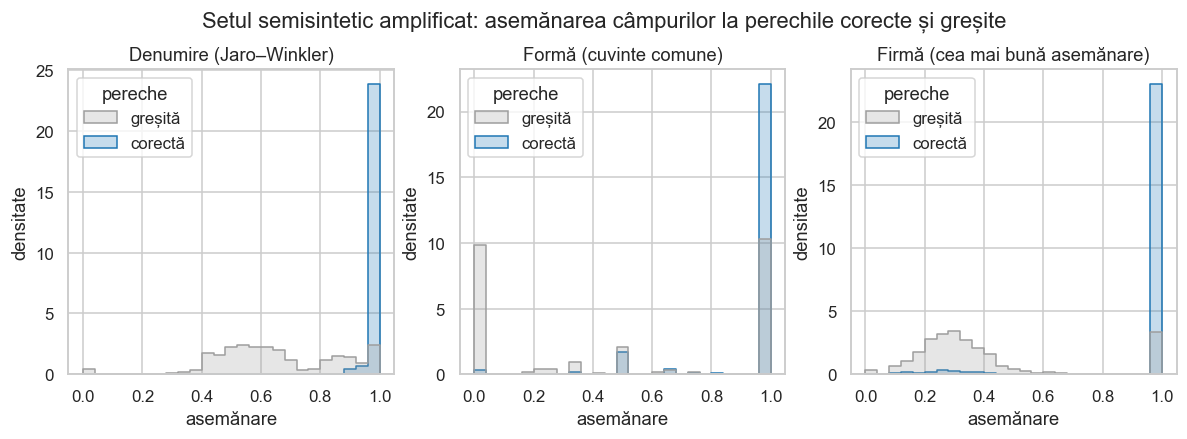

In [12]:
# Figura 9: distribuția scorurilor de asemănare pentru perechile corecte și greșite (setul amplificat)
v = ss["amplificat"]["vec"].assign(pereche=lambda d: d.potrivire.map({1: "corectă", 0: "greșită"}))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, title in zip(axes, ["sim_denumire", "sim_forma", "sim_firma"],
                          ["Denumire (Jaro–Winkler)", "Formă (cuvinte comune)", "Firmă (cea mai bună asemănare)"]):
    sns.histplot(v, x=col, hue="pereche", stat="density", common_norm=False, bins=25, element="step",
                 hue_order=["greșită", "corectă"], palette={"greșită": "#9e9e9e", "corectă": "#1f77b4"}, ax=ax)
    ax.set_title(title); ax.set_xlabel("asemănare"); ax.set_ylabel("densitate")
fig.suptitle("Setul semisintetic amplificat: asemănarea câmpurilor la perechile corecte și greșite", y=1.03)
fig.savefig(FIG / "fig09_scoruri_comparare.png")
plt.show()

**Ce am obținut.** Figura 9 arată că la perechile corecte toate cele trei scoruri sunt concentrate aproape de 1. La perechile greșite, asemănarea denumirii este împrăștiată între 0,4 și 0,9, iar asemănarea firmei între 0,1 și 0,5. Ambele au totuși un vârf la 1, care corespunde celorlalte ambalaje sau doze ale aceleiași mărci. Pentru formă vârful perechilor greșite la valoarea 1 este și mai mare. Aceste perechi greșite pot fi deosebite doar prin doză, numărul de unități și volum, motiv pentru care vectorul de comparare trebuie să conțină toate câmpurile.

**Ce căutăm.** Modelul Fellegi–Sunter descrie fiecare câmp prin două probabilități pentru fiecare nivel de acord. Probabilitatea m este probabilitatea nivelului când perechea este corectă. Probabilitatea u este probabilitatea aceluiași nivel când perechea este greșită. Pe setul semisintetic le putem calcula direct, pentru că știm eticheta. Ele ne vor servi în notebook-ul următor ca punct de comparație pentru valorile estimate de algoritmul EM fără etichete.

In [13]:
v = ss["amplificat"]["vec"]
rows = []
for col in LEVEL_COLS:
    t = pd.crosstab(v[col], v.potrivire, normalize="columns")      # proporții pe coloane: m (1) și u (0)
    for lvl in t.index:
        m_, u_ = t.loc[lvl, 1], t.loc[lvl, 0]
        rows.append({"câmp": col.replace("niv_", ""), "nivel": int(lvl), "m": m_, "u": u_,
                     "pondere log2(m/u)": np.log2(m_ / u_) if m_ > 0 and u_ > 0 else np.nan})
mu = pd.DataFrame(rows).round(4)
mu

,câmp,nivel,m,u,pondere log2(m/u)
0,denumire,0,0.0000,0.7029,NaN
1,denumire,1,0.0194,0.1650,-3.0875
2,denumire,2,0.0895,0.0473,0.9212
3,denumire,3,0.8911,0.0848,3.3932
4,doza,0,0.0016,0.6845,-8.7334
5,doza,1,0.0084,0.0425,-2.3455
6,doza,2,0.9900,0.2730,1.8584
7,forma,0,0.0229,0.4738,-4.3716
8,forma,1,0.0941,0.1141,-0.2778
9,forma,2,0.8830,0.4121,1.0994


**Ce am obținut.** Ponderea log2(m/u) arată cât crește sau scade încrederea într-o potrivire când apare nivelul respectiv. Cele mai puternice dovezi pentru potrivire sunt denumirea identică, cu o pondere de 3,39, firma foarte asemănătoare, cu 2,76, doza egală, cu 1,86, numărul de unități egal, cu 1,74, și volumul egal, cu 1,49. Forma egală aduce doar 1,10, iar substanța activă egală doar 0,21, pentru că blocarea face ca aproape toți candidații să aibă aceeași substanță. Cele mai puternice dovezi împotriva potrivirii sunt doza diferită, cu −8,73, forma diferită, cu −4,37, și firma diferită, cu −3,43. Patru niveluri nu apar deloc la perechile corecte, și anume denumirea complet diferită, numărul de unități diferit, volumul diferit și substanța diferită, așa că ponderea lor nu poate fi calculată. În datele reale ele pot apărea totuși, prin greșeli ale surselor, deci modelul din notebook-ul următor va trebui să le atribuie o probabilitate mică, dar nenulă.

**Constatare 5.** Pe setul semisintetic, blocarea reduce comparațiile cu 99,66% și păstrează 99,97% dintre perechile corecte în varianta realistă și 99,94% în cea amplificată. Vectorul de comparare separă clar perechile corecte de cele greșite. Cele mai informative câmpuri sunt denumirea, firma, doza și numărul de unități, iar forma și substanța activă aduc puțină informație suplimentară după blocare.

## 6. Seamănă setul semisintetic cu lista CNAM?

**Ce căutăm.** Setul semisintetic este util doar dacă seamănă cu datele reale. Pentru fiecare rând, în CNAM și în cele două variante ale setului, luăm candidatul cel mai asemănător și calculăm cât de des este fiecare câmp identic. Dacă setul realist este bine construit, proporțiile lui trebuie să fie apropiate de cele din CNAM, iar setul amplificat trebuie să fie vizibil mai dificil.

                                              CNAM  semisintetic realist  semisintetic amplificat
denumire identică                             93.5                  92.5                     79.9
denumire foarte asemănătoare (JW ≥ 0,92)      94.8                  95.1                     88.9
doză egală                                    99.2                  98.6                     95.7
formă egală                                   97.6                  96.3                     87.2
unități egale                                 98.0                  99.4                     98.3
firmă asemănătoare (≥ 0,9)                    89.7                  94.4                     84.6
denumire, doză și formă fără nicio diferență  90.5                  89.9                     70.2


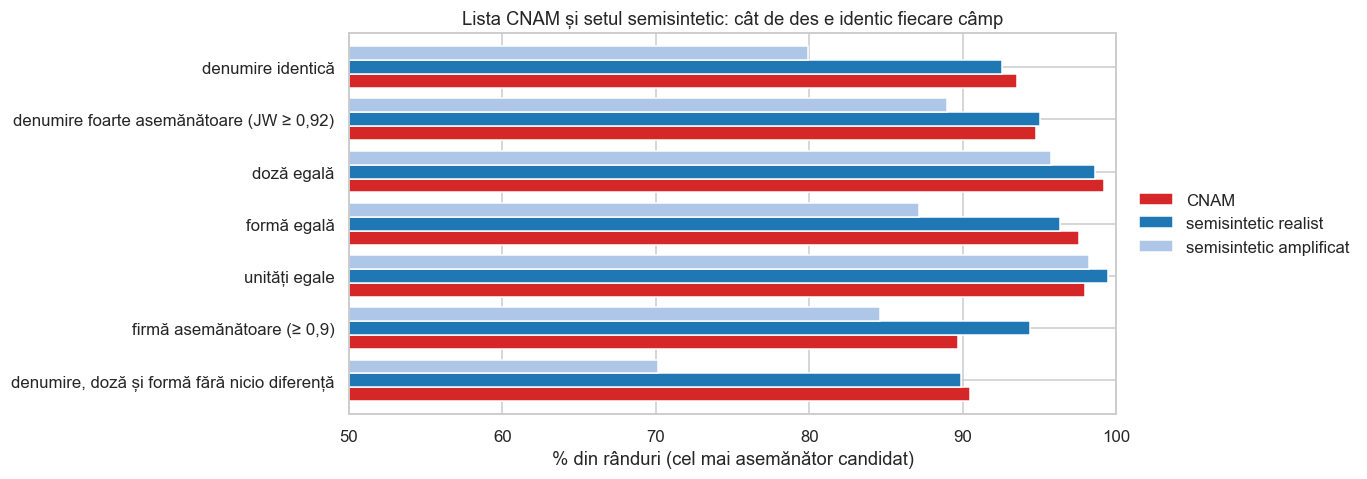

In [14]:
def best_profile(vec):
    # candidatul cel mai asemănător al fiecărui rând (același scor simplu ca la perechile probabile);
    # proporțiile se calculează doar pe valorile prezente în ambele surse (lipsa nu e nici acord, nici dezacord)
    score = (vec.sim_denumire.fillna(0) + vec.eq_doza.fillna(.5) + vec.eq_forma.fillna(.5)
             + vec.eq_unitati.fillna(.5) + vec.sim_firma.fillna(.5))
    b = vec.loc[score.groupby(vec.ia).idxmax()]
    share = lambda cond, col: cond[b[col].notna()].mean()
    return pd.Series({"denumire identică": share(b.niv_denumire == 3, "niv_denumire"),
                      "denumire foarte asemănătoare (JW ≥ 0,92)": share(b.sim_denumire >= 0.92, "sim_denumire"),
                      "doză egală": share(b.eq_doza == 1, "eq_doza"),
                      "formă egală": share(b.eq_forma == 1, "eq_forma"),
                      "unități egale": share(b.eq_unitati == 1, "eq_unitati"),
                      "firmă asemănătoare (≥ 0,9)": share(b.sim_firma >= 0.9, "sim_firma"),
                      "denumire, doză și formă fără nicio diferență":
                          ((b.niv_denumire == 3) & (b.eq_doza != 0) & (b.eq_forma == 1)).mean()})

profil = pd.DataFrame({"CNAM": best_profile(vec_cnam),
                       "semisintetic realist": best_profile(ss["realist"]["vec"]),
                       "semisintetic amplificat": best_profile(ss["amplificat"]["vec"])}) * 100
print(profil.round(1).to_string())

# Figura 10: același profil, ca grafic
ax = profil.iloc[::-1].plot.barh(figsize=(9, 4.5), color=["#d62728", "#1f77b4", "#aec7e8"], width=0.8)
ax.set_xlabel("% din rânduri (cel mai asemănător candidat)"); ax.set_xlim(50, 100)
ax.set_title("Lista CNAM și setul semisintetic: cât de des e identic fiecare câmp")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.savefig(FIG / "fig10_profil_cnam_semisintetic.png")
plt.show()

**Ce am obținut.** Setul realist reproduce îndeaproape profilul listei CNAM. Denumirea este identică în 92,5% din rânduri, față de 93,5% în CNAM, doza este egală în 98,6% față de 99,2%, forma în 96,3% față de 97,6%, iar denumirea, doza și forma sunt toate fără diferențe în 89,9% față de 90,5%. Cea mai mare abatere apare la firmă. Firma este foarte asemănătoare în 94,4% din rândurile setului realist, dar doar în 89,7% din cele CNAM, deci firmele diferă în realitate mai des decât am simulat. O explicație este că nu schimbăm firma la denumirile generice, unde o firmă diferită înseamnă alt produs. Setul amplificat este, cum ne-am propus, vizibil mai dificil, cu doar 70,2% dintre rânduri fără nicio diferență la denumire, doză și formă.

**Constatare 6.** Setul semisintetic realist reproduce profilul listei CNAM cu o abatere de cel mult 1,4 puncte procentuale la denumire, doză, formă și numărul de unități. Excepția este firma, care în CNAM diferă mai des cu aproximativ 4,7 puncte procentuale. Această diferență trebuie menționată ca limită, iar rezultatele modelelor trebuie verificate în final pe rândurile CNAM etichetate manual.

## 7. Rezumat și pașii următori

Am construit în acest notebook pașii care pregătesc potrivirea probabilistă. Normalizarea a fost completată cu substanța activă redusă la rădăcini, cu numele firmei și cu divizarea exprimată ca număr total de unități și volum. Blocarea reduce comparațiile cu peste 99% fără să piardă practic nicio pereche corectă, iar vectorul de comparare descrie fiecare pereche prin scoruri continue, pentru modelele de clasificare, și prin niveluri de acord, pentru modelul Fellegi–Sunter. Setul semisintetic, construit din Catalog cu variațiile și frecvențele măsurate în CNAM, oferă exemple cu răspuns cunoscut și reproduce bine profilul listei reale. Răspunsul corect este definit la nivelul clasei de produs, deoarece Nomenclatorul dă uneori coduri diferite aceleiași cantități ambalate diferit.

În pasul următor vom estima modelul Fellegi–Sunter prin algoritmul EM, fără etichete, și vom compara probabilitățile m și u estimate cu cele cunoscute din setul semisintetic. Apoi vom antrena regresia logistică, un model SVM și o rețea neuronală pe setul amplificat și le vom evalua pe setul realist, iar în final pe rândurile CNAM etichetate manual.

**Ce căutăm.** Salvăm în folderul data/interim tot ce are nevoie pasul următor. Pentru fiecare variantă a setului semisintetic salvăm rândurile modificate, copia Nomenclatorului și perechile candidate cu vectorul de comparare și eticheta. Pentru lista CNAM salvăm perechile candidate cu vectorul de comparare, fără etichetă, împreună cu sursele completate cu câmpurile noi.

In [15]:
saved = []                                                 # fișierele scrise de acest notebook
for name, d in ss.items():
    for f, df, label in [(f"semisintetic_{name}_a.csv", d["a"], "ia"), (f"semisintetic_{name}_b.csv", d["b"], "ib")]:
        df.to_csv(INTERIM / f, index_label=label); saved.append(f)
    d["vec"].to_csv(INTERIM / f"perechi_semisintetic_{name}.csv", index=False); saved.append(f"perechi_semisintetic_{name}.csv")
vec_cnam.merge(pairs_cnam, on=["ia", "ib"]).to_csv(INTERIM / "perechi_cnam.csv", index=False); saved.append("perechi_cnam.csv")
ro.to_csv(INTERIM / "cnam_ro_link.csv", index_label="ia"); saved.append("cnam_ro_link.csv")
n.to_csv(INTERIM / "nomenclator_link.csv", index_label="ib"); saved.append("nomenclator_link.csv")
print(sorted(saved))

['cnam_ro_link.csv', 'nomenclator_link.csv', 'perechi_cnam.csv', 'perechi_semisintetic_amplificat.csv', 'perechi_semisintetic_realist.csv', 'semisintetic_amplificat_a.csv', 'semisintetic_amplificat_b.csv', 'semisintetic_realist_a.csv', 'semisintetic_realist_b.csv']


**Ce am obținut.** Au fost salvate nouă fișiere. Pentru fiecare variantă a setului semisintetic există rândurile modificate, copia Nomenclatorului și fișierul cu perechi, vectorul de comparare și eticheta. Pentru lista CNAM există fișierul perechi_cnam.csv, cu perechile candidate și vectorul de comparare, iar sursele completate cu noile câmpuri sunt salvate în cnam_ro_link.csv și nomenclator_link.csv.